# Keyword spam model MVP

## Setup

You'll need to download en_core_web_sm for this task

In [1]:
# ! uv pip install https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl

In [2]:
# import nltk

# nltk.download("punkt_tab")

In [3]:
from itertools import chain
import os
import pandas as pd
import numpy as np
import re
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy
import truecase
import xgboost as xgb
import unidecode

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)
pd.set_option("display.max_colwidth", None)
nlp = spacy.load("en_core_web_sm")

## Useful feature engineering functions

In [4]:
def proportion_of_stopwords(description):
    tokens = description.split(" ")
    num_stopwords = len(
        [word for word in tokens if word.lower() in nlp.Defaults.stop_words]
    )
    return float(num_stopwords) / float(len(tokens)) if len(tokens) else 0.0


def average_length_of_word(description):
    tokens = description.split(" ")
    return np.mean([len(word) for word in tokens]) if len(tokens) else 0.0


# Only if the entire word is digit will this consider the word being digit
# Ignore words where digit is part of the word e.g. y2k [Done]
def proportion_of_numbers(description):
    tokens = description.split(" ")
    num_digits = len([word for word in tokens if word.isdigit()])
    return float(num_digits) / float(len(tokens)) if len(tokens) else 0.0


def normalise_nonascii_chars(input_str):
    return unidecode.unidecode(input_str)


# This is removing hash tags. Spammy descriptions could have lots of hashtags
# Could be removing legitimate signals [Done]
def replace_special_chars(main_string):
    return re.sub("[,;@#!\?\+\*\n\-: /]", " ", main_string)


def keep_alphanumeric_chars(string_input):
    return re.sub("[^A-Za-z0-9& ]", "", string_input)


def remove_spaces(string_input):
    return " ".join(string_input.split())


def lemmatize(string_input):
    token_object = nlp(string_input)
    lemmas_list = [
        word.lemma_ if word.lemma_ != "-PRON-" else word.text for word in token_object
    ]
    return " ".join(lemmas_list)


def drop_digits(s):
    return "".join([i for i in s if not i.isdigit()])


def clean_description(input_str):
    input_str = replace_special_chars(input_str.lower())
    input_str = normalise_nonascii_chars(input_str)
    input_str = keep_alphanumeric_chars(input_str)
    input_str = lemmatize(input_str)
    input_str = remove_spaces(input_str)
    return input_str

## SK Learn Pipeline

In [5]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer


class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X):
        df = X.copy()
        # Clean description
        df["description"] = df["description"].apply(clean_description)
        # Feature engineering on cleaned decription
        df["proportion_of_stopwords"] = df["description"].apply(proportion_of_stopwords)
        df["average_length_of_word"] = df["description"].apply(average_length_of_word)
        df["proportion_of_numbers"] = df["description"].apply(proportion_of_numbers)
        # Drop digits, true case, then get perform entity recognition
        df["description"] = df["description"].apply(drop_digits)
        df["description_truecase"] = df["description"].apply(truecase.get_true_case)
        df["description_nlp"] = df["description_truecase"].apply(nlp)

        df["named_entities"] = ""

        for i, description_nlp in df["description_nlp"].items():
            named_entities_sets = description_nlp.ents
            named_entities = list(set(chain(*named_entities_sets)))
            df["named_entities"].at[i] = " ".join(j.text for j in named_entities)

        return df


column_transformer = ColumnTransformer(
    transformers=[
        (
            "named_entities_tfidf",
            TfidfVectorizer(
                stop_words=list(nlp.Defaults.stop_words),
                max_features=500,
            ),
            "named_entities",
        ),
        (
            "description_tfidf",
            TfidfVectorizer(
                stop_words=list(nlp.Defaults.stop_words),
                max_features=500,
            ),
            "description",
        ),
        (
            "manual_features",
            "passthrough",
            [
                "proportion_of_stopwords",
                "average_length_of_word",
                "proportion_of_numbers",
            ],
        ),
    ],
    remainder="drop",
)


class DenseTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X):
        return X.toarray() if hasattr(X, "toarray") else X

In [6]:
from sklearn.pipeline import Pipeline

feature_processing_pipeline = Pipeline(
    steps=[
        ("feature_engineering", FeatureEngineering()),
        ("features", column_transformer),
        # Avoid returning a dense matrix as it would force materialisation of zeros
        # Which could cause memory explosion if we need > 500 TFIDF features
        # ("to_dense", DenseTransformer()),
    ]
)

In [7]:
cwd = os.getcwd()

df_train = pd.read_csv(os.path.join(cwd, "../data/train_set.tsv"), sep="\t")[
    ["product_id", "description", "label"]
]

df_train = df_train.reset_index(drop=True)

X_train = df_train.drop(columns=["label"]).copy()
y_train = df_train["label"].copy()

print("Transforming X_train..")
X_train = feature_processing_pipeline.fit_transform(X_train)

print("Reading test data..")
# Do not touch df_test until final eval to avoid data leakage
df_test = pd.read_csv(os.path.join(cwd, "../data/test_set.tsv"), sep="\t")[
    ["product_id", "description", "label"]
]
X_test = df_test.drop(columns=["label"]).copy()
y_test = df_test["label"].copy()

print("Transform X_test without fitting...")
X_test = feature_processing_pipeline.transform(X_test)

Transforming X_train..


/Users/shengy/Documents/GitHub/depop_takehome_task/.venv/lib/python3.11/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Reading test data..
Transform X_test without fitting...


# Hyperparam Tuning and Fit model

In [8]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split


# Keep X_test untouched for final evaluation.

# X_train_proper used for training the model
# X_calib is used only for model calibration.
X_train_proper, X_calib, y_train_proper, y_calib = train_test_split(
    X_train,
    y_train,
    test_size=0.3,
    stratify=y_train,
    random_state=42,
)

# X_train_tune to perform CV search and refit model on best params
# X_train_eval is used only for XGBoost early stopping.
X_train_tune, X_train_eval, y_train_tune, y_train_eval = train_test_split(
    X_train_proper,
    y_train_proper,
    test_size=0.2,
    stratify=y_train_proper,
    random_state=42,
)

# 500 trees with early stopping for 5 rounds for illustrative purpose only
# In reality we could go even higher
base_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    n_estimators=500,
    early_stopping_rounds=5,
    tree_method="hist",
    random_state=42,
    n_jobs=1,
)

param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
    "min_child_weight": [1, 5],
    "subsample": [0.8, 1.0],
    "reg_lambda": [0.1, 1.0],
}

# Do only three fits to reduce compute time
# But in reality we want to have ~ 5 splits
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42,
)

# Note, there's still potential data leakage here
# For each CV fold, tf-idf was trained on the whole x_train_proper
# Really we should be doing tf-idf inside each CV split, but that will
# significantly increase iteration time
# for demonstration purpose we'll ignore it
# e.g.
# ```
# cv_pipeline = Pipeline(steps=[feature_engineering(), TFIDF(), XGBClassifier()])
# then GridSearchCV(estimator=cv_pipeline)
# ```
grid_search = GridSearchCV(
    estimator=base_clf,
    param_grid=param_grid,
    scoring="f1",  # Scoring with F1 instead of accuracy
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True,
    error_score="raise",
)

grid_search.fit(
    X_train_tune,
    y_train_tune,
    eval_set=[(X_train_eval, y_train_eval)],
    verbose=False,
)

clf = grid_search.best_estimator_

print(f"Best CV F1: {grid_search.best_score_:.4f}")
print(f"Best params: {grid_search.best_params_}")
print(f"Best iteration: {clf.best_iteration}")

Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best CV F1: 0.9300
Best params: {'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'reg_lambda': 0.1, 'subsample': 0.8}
Best iteration: 96


In [21]:
# Fit final model on whole X_train_proper. Do not touch X_train_calib which is used for calibration, and X_test for final evaluation.
final_base_clf = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=1,
    **grid_search.best_params_,
    n_estimators=clf.best_iteration + 1,
)

final_base_clf.fit(
    X_train_proper,
    y_train_proper,
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=97, n_jobs=1,
              num_parallel_tree=None, ...)

## Predict on model

In [10]:
y_train_proper_pred = final_base_clf.predict(X_train_proper)
y_test_pred = final_base_clf.predict(X_test)

## Evaluate

In [11]:
# Data set mean is 58%? Is this a realisitic expectation for distribution of spams? I'd expect spams to be less prevalent
# If training set distribution is not the same as real world distribution -> calibration of model will be off..
print(df_train["label"].mean())
print(df_test["label"].mean())

0.598
0.528


In [12]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train_proper, y_train_proper_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Train Accuracy: {(train_accuracy * 100.0):.2f}%")
print(f"Test Accuracy: {(test_accuracy * 100.0):.2f}%")

Train Accuracy: 98.76%
Test Accuracy: 96.40%


F1 score: 0.9661654135338346
Recall: 0.9734848484848485
Precision: 0.9589552238805971
              precision    recall  f1-score   support

           0       0.97      0.95      0.96       236
           1       0.96      0.97      0.97       264

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



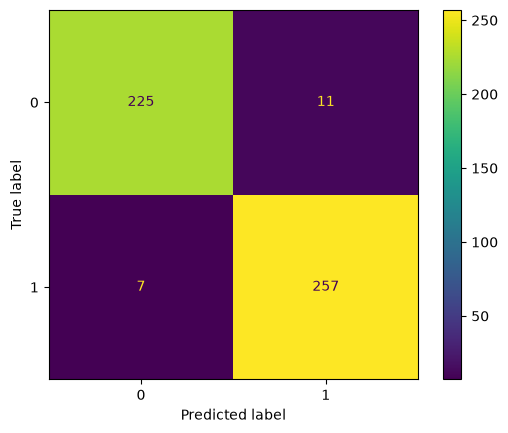

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

print(f"F1 score: {f1_score(y_test, y_test_pred)}")
print(f"Recall: {recall_score(y_test, y_test_pred)}")
print(f"Precision: {precision_score(y_test, y_test_pred)}")
print(classification_report(y_test, y_test_pred, labels=[0, 1]))

cm = confusion_matrix(y_test, y_test_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot()

PR-AUC / Average Precision: 0.9475


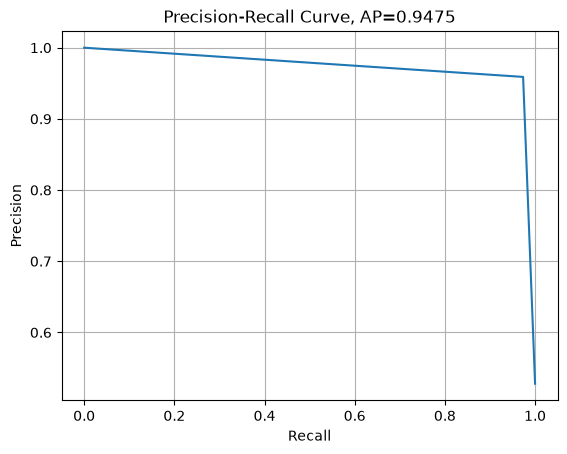

In [14]:
from sklearn.metrics import average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt

ap = average_precision_score(y_test, y_test_pred)
print(f"PR-AUC / Average Precision: {ap:.4f}")

precision, recall, thresholds = precision_recall_curve(y_test, y_test_pred)

plt.figure()
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve, AP={ap:.4f}")
plt.grid(True)
plt.show()

## Model Calibration

In [15]:
import matplotlib.pyplot as plt

from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay

CALIBRATION_BINS = 5


def ece(y_true, y_prob, n_bins=CALIBRATION_BINS):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(y_prob, bins[1:-1])

    return sum(
        np.mean(bin_ids == i)
        * abs(np.mean(y_true[bin_ids == i]) - np.mean(y_prob[bin_ids == i]))
        for i in range(n_bins)
        if np.any(bin_ids == i)
    )


models = {
    "Uncalibrated": final_base_clf,
    "Platt scaling": CalibratedClassifierCV(
        FrozenEstimator(final_base_clf),
        method="sigmoid",
    ).fit(X_calib, y_calib),
    "Isotonic regression": CalibratedClassifierCV(
        FrozenEstimator(final_base_clf),
        method="isotonic",
    ).fit(X_calib, y_calib),
}

In [16]:
results = {
    name: {
        "proba": model.predict_proba(X_test)[:, 1],
    }
    for name, model in models.items()
}

for name, result in results.items():
    result["ece"] = ece(y_test, result["proba"])
    print(f"{name} ECE: {result['ece']:.4f}")

Uncalibrated ECE: 0.0249
Platt scaling ECE: 0.0145
Isotonic regression ECE: 0.0134


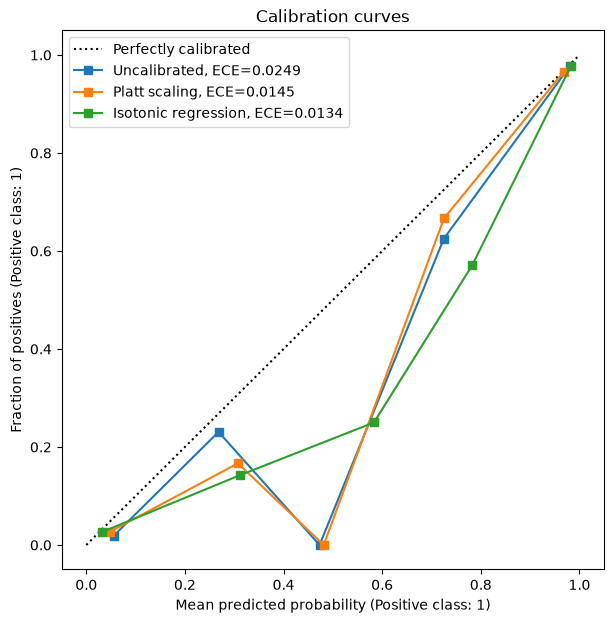

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))

for name, result in results.items():
    CalibrationDisplay.from_predictions(
        y_true=y_test,
        y_prob=result["proba"],
        n_bins=CALIBRATION_BINS,
        strategy="uniform",
        name=f"{name}, ECE={result['ece']:.4f}",
        ax=ax,
    )

ax.set_title("Calibration curves")
ax.legend()
plt.show()

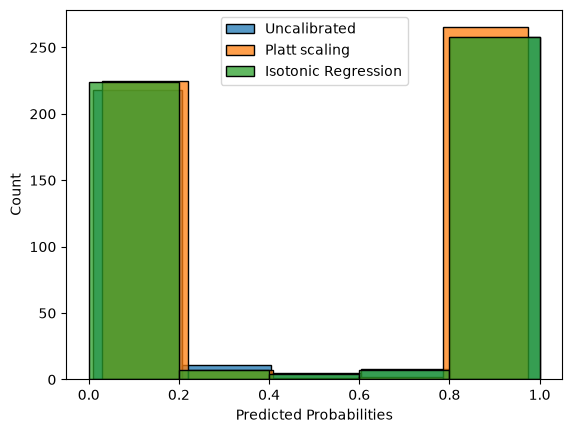

In [18]:
import seaborn as sns


sns.histplot(
    results["Uncalibrated"]["proba"], label="Uncalibrated", bins=CALIBRATION_BINS
)
sns.histplot(
    results["Platt scaling"]["proba"], label="Platt scaling", bins=CALIBRATION_BINS
)
sns.histplot(
    results["Isotonic regression"]["proba"],
    label="Isotonic Regression",
    bins=CALIBRATION_BINS,
)
plt.xlabel("Predicted Probabilities")
plt.legend()

In [19]:
from sklearn.metrics import brier_score_loss, log_loss

for name, model in models.items():
    y_pred_label = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    f1 = f1_score(y_test, y_pred_label)
    precision = precision_score(y_test, y_pred_label)
    recall = recall_score(y_test, y_pred_label)
    accuracy = accuracy_score(y_test, y_pred_label)
    brier = brier_score_loss(y_test.squeeze(), y_pred_proba.squeeze())
    ll = log_loss(y_test, y_pred_proba)
    ce = ece(y_test, y_pred_proba)

    print(f"{name}")
    print(f"  F1 score:  {f1:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  Accuracy:  {accuracy:.2%}")
    print(f"  Brier:     {brier:.6f}")
    print(f"  Log Loss:  {ll:.4f}")
    print(f"  Expected Calibration Score: {ce:.4f}")

Uncalibrated
  F1 score:  0.9662
  Precision: 0.9590
  Recall:    0.9735
  Accuracy:  96.40%
  Brier:     0.031000
  Log Loss:  0.1252
  Expected Calibration Score: 0.0249
Platt scaling
  F1 score:  0.9662
  Precision: 0.9590
  Recall:    0.9735
  Accuracy:  96.40%
  Brier:     0.031428
  Log Loss:  0.1311
  Expected Calibration Score: 0.0145
Isotonic regression
  F1 score:  0.9644
  Precision: 0.9554
  Recall:    0.9735
  Accuracy:  96.20%
  Brier:     0.030884
  Log Loss:  0.1217
  Expected Calibration Score: 0.0134


## Check features

In [20]:
feature_names = feature_processing_pipeline.named_steps[
    "features"
].get_feature_names_out()

features = pd.DataFrame(
    {
        "feature_name": feature_names,
        "feature_importance": clf.feature_importances_,
    }
).sort_values("feature_importance", ascending=False)

features.query("feature_importance > 0.0")

,feature_name,feature_importance
494,named_entities_tfidf__yk,0.038116
1000,manual_features__proportion_of_stopwords,0.037120
542,description_tfidf__blue,0.028020
987,description_tfidf__white,0.027769
933,description_tfidf__summer,0.026679
806,description_tfidf__nike,0.025337
976,description_tfidf__vintage,0.022609
939,description_tfidf__tag,0.022052
906,description_tfidf__size,0.019915
1002,manual_features__proportion_of_numbers,0.017934


# Summary of Change log

1. Fixed data leakage by:
    - using sklearn pipeline to preprocess and fit on training data, then transform test data
    - model is only trained on **train** data -> test data is unseen until evaluation
    - pipeline also is a clearly defined step that makes it easy for us to ship in production

2. Fixed training issues:
    - implement hyperparameter tuning steps using StratifedKFold to make sure each CV split has the same distribution of targets
    - using eval set for early stopping
    - refit model on data using best parameters
    - avoid .to_dense() -> feed original sparse matrix into XGBoost to avoid memory issues if we do need to increase TF-IDF vocab size.

3. Explore evaluation criteria:
    - Instead of relying solely on accuracy, also report F1 score to take into account cost asymmetry of false positives vs false negatives
    - false positives -> bad for sellers as legitimate listings get taken down. false negative -> bad for buyers as they see spammy listings
    - if we're feeding this into recommendation, we might want to combine probabilities -> therefore probabilities must be calibrated
    - using platt scaling and isotonic regression to calibrate model and check for calibration errors to confirm probabilities are good

# Remaining questions to explore:
1. A spam dataset with 56% true label doesn't feel natural. I'd expect the dataset to be a lot more imbalance. It's worth confirming this, as training a model on a distribution that is not representative of the real world would throw off calibration curves. I would avoid resampling to avoid training on imbalanced dataset. And calibration should always be done on a independent dataset that is representative of the real world.
2. Explore TF-IDF further:
    - Some of the TF-IDF terms picked up by the model looks suspicious e.g. white/ blue. Is this correlation real?
    - Is vocab size of 500 enough? TF-IDF could be a tunable parameter

# For future

Focussed on trustworthy evaluation first, prior to fixing feature engineering issues. Reasons:
1. It's important to make sure evalutation framework is right first before devoting time to do extensive feature engineering
2. After fixing evaluation, it's showing that current feature engineering steps is pretty decent compared to a dummy model (60% vs 96%)
3. Return of investment of feature engineering is limited here, unless the remaining 4% has material impact on the business to justify further investment

If we need to further optimise on the remaining 4% of performance, ideas are:

---

### 1. More feature engineering to identify spammy terms such as:
- `hashtags`: signature of spammy posts e.g. number of hashtags terms, length of hashtagged terms as % of total descriptions, unique hashtags
- `brand`: brand-name detected e.g. number of brands 
- `adjectives`: repeated adjectives, or uniqueness/ synonyms, diversity of adjectives mentioned, % of adjective length / total description length
- `style`: style terms detected e.g. `y2k`, `90s`, `street wear`, `athleisure` etc, 
- `sizing`: sizing terms detected, e.g. uniquness, repetition, many sizing values, etc
- `seller`: mine for other seller related info (e.g. % of past listings detected as spammy) - if the seller previously has many spammy listing, chances are all listings are also spammy, but beware for changing behaviour (e.g. sellers stopped spamming - various rolling metrics to help spot trend)

---

### 2. Using a more specialised method of fashion-related NER, e.g. detecting fashion brands, or fashion styles/ terms etc:

**a. Naive brand dictionary**
- Start with a basic dictionary of known fashion brand in Depop's own catalogue/ brand filters
- Normalise brand names e.g. lowercasing, remove punctuation and accents, handling known aliases e.g. `ysl` -> `yves saint laurent`, `lv` -> `louis vuitton`
- Longest span matching instead of token by token matching to detect compound brand names e.g. `river island`

- Pros: fast/ cheap, explicit, but may miss many unknown terms/ long tail distribution of unlisted names/ terms. 
- Cons: Can go stale pretty quickly if terms fall out of fashion.


**b. Besoke NER model for fashion brands or terms**
a. Recognise the category of spans e.g. `BRAND`, `STYLE`, `SIZE`, `MATERIAL`, `AESTHETIC`
b. Annotation guidelines: what counts as a brand, handling abbreviations and mispellings
c. Start with weak labels from dictionary -> manually review and correct sample and retrain via active learning
d. Evaluate via span-level precision, recall, F1. For known issues e.g. compound terms, have separate metrics for each dimension (e.g. single-token brands, multi-token brands etc)

- Pros: a model can to automatically detect terms without previously seeing them before
- Cons: modelling complexity, active learning loop, require human annotation

Example of method:
- sklearn-crfsuite: a sklearn api wrapper for CRF (continuous random field) - HMM-based method
- SpaCy's `EntityRecognizer`: neural-network based method to learn state transition probabilities
- DistilBertForTokenClassification: distil bert model with classification head for token classification (NER)

How this help with spam classification:
- Identify all the brand entities, style, descriptors, in description, then do a count of the terms e.g. number of unique brand mentioned etc

Deploying this in production:
- seller creates listing -> API call do model endpoint hosting NER -> output tags -> call spam classifier endpoint -> run pipeline to convert tagged sentences into features -> predict spam probability

---

### 3. Using embeddings in addition to TF-IDF
- Embeddings produces dense vectors that can capture semantic relationships
- Use embedding as is, or use embeddings for feature engineering:
    - cosine similiarty of description to title
    - cosine similarity of description to image (CLIP style embeddings to project text and image embedding to the same space)
    - similarity score can be used for spam classification


**Options:**
- Open-source embeddings e.g GloVE (word based, may not have seen the fashion terms we're interested in) - but free
- Closed-source model embeddings e.g. https://developers.openai.com/api/docs/models/text-embedding-3-small - no ML infrastructure to maintain but comes at a cost
- Fine-tune trained embeddings on fashion data
- Train our own embedding

Other benefits of embeddings: used elsewhere across the business e.g. recommendations

Proposed sequential approach:
1. Prototype with closed-sourced model embeddings e.g. OpenAPI on small scale data. 
    - If promising, estimate cost on production scale. If acceptable, stop here. 
    - If too expensive then 👇..
2. Open-sourced pre-trained word embeddings 
    - e.g. GloVE, fasttext etc. pros: no need to retrain. cons: might not capture fashion specific context.
    - If acceptible, stop here. If not 👇..
3. Use frozen open-sourced embedding models. 
    - e.g. DistilBertModel - output raw hiddens states (embeddings). Test a few different models on HF hub.
    - pros: models are trained on huge text corpus, might be enough for our use case. cons: may not fully capture fashion-specific words.
    - If good enough, stop here. If performance isn't good enough 👇..
3. Fine-tune open-sourced embedding on internal dataset:
    - pros: not learning from scratch, but taking pre-trained weights to optimised on fashion data

Future: joint embeddings of image and text. Only work on this if we can prove text embeddings are adding value.

Deploying this in production:
- seller creates listing -> API call do model endpoint hosting embedding model -> Outputs embeddings -> Calls spam classifier -> takes embeddings to use as features + compute similarity scores as features